# Imports

In [1]:
import os
import keras
import numpy as np
import gymnasium as gym
import tensorflow as tf
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Environment

Create the [environment](https://gymnasium.farama.org/environments/box2d/bipedal_walker/).

In [3]:
ENV_NAME = "BipedalWalker-v3"

env = gym.make(ENV_NAME, hardcore=False)
eval_env = gym.make(ENV_NAME, hardcore=False)

OBS_DIM = env.observation_space.shape[0]
ACT_DIM = env.action_space.shape[0]
ACT_LOW = float(env.action_space.low[0])
ACT_HIGH = float(env.action_space.high[0])

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print(f"Action range: [{ACT_LOW}, {ACT_HIGH}]")

Observation space: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)
Action space: Box(-1.0, 1.0, (4,), float32)
Action range: [-1.0, 1.0]


C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# Replay Buffer

Create a replay buffer to hold game history

In [4]:
class ReplayBuffer:

    def __init__(self, max_size: int, observation_space: gym.spaces.Space, action_space: gym.spaces.Space, seed: int | None = None):
        """Stores the replay history with a maximum of `max_size` entries, removing old entries as needed."""
        self.max_size = max_size
        self.observation_space = observation_space
        self.action_space = action_space

        self.current_observations = np.empty((max_size, *observation_space.shape), dtype=np.float32)
        self.actions = np.empty((max_size, *action_space.shape), dtype=np.float32)
        self.rewards = np.empty((max_size,), dtype=np.float32)
        self.next_observations = np.empty((max_size, *observation_space.shape), dtype=np.float32)
        self.dones = np.empty((max_size,), dtype=bool)

        self.current_size = 0
        self.current_index = 0

        self.rng = np.random.default_rng(seed)

    def add(self, current_observations: np.ndarray, actions: np.ndarray, rewards: np.ndarray, next_observations: np.ndarray, dones: np.ndarray) -> None:
        """Add a new entry to the buffer."""
        n = len(actions)
        index = (np.arange(n) + self.current_index) % self.max_size
        self.current_observations[index] = current_observations
        self.actions[index] = actions
        self.rewards[index] = rewards
        self.next_observations[index] = next_observations
        self.dones[index] = dones

        self.current_index = (index[-1] + 1) % self.max_size
        self.current_size = min(self.max_size, self.current_size + n)

    def sample(self, n_samples: int, replace: bool = True) -> tuple:
        """Randomly samples `n_samples` from the buffer."""
        sample_indices = self.rng.choice(self.current_size, size=n_samples, replace=replace)
        return self[sample_indices]

    def clear(self) -> None:
        """Clears the buffer"""
        self.current_index = 0
        self.current_size = 0

    def __getitem__(self, index):
        return (
            self.current_observations[index],
            self.actions[index],
            self.rewards[index],
            self.next_observations[index],
            self.dones[index],
        )

    def __len__(self) -> int:
        return self.current_size

# Model

Implement actor and critic.

We use two hidden layers of size 256 with `LayerNormalization`, which stabilises DDPG training a lot — much better than the plain 400/300 architecture from the original paper.

In [5]:
def build_actor(obs_dim: int, act_dim: int) -> keras.Model:
    """Policy network. Outputs actions in [-1, 1]."""
    inp = keras.Input(shape=(obs_dim,))
    x = keras.layers.Dense(256)(inp)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.Dense(256)(x)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    out = keras.layers.Dense(act_dim, activation="tanh", kernel_initializer=keras.initializers.RandomUniform(-3e-3, 3e-3),)(x)
    return keras.Model(inp, out, name="actor")

# def build_critic(obs_dim: int, act_dim: int) -> keras.Model:
#     """Q-function network. Q(s, a) -> R."""
#     obs_inp = keras.Input(shape=(obs_dim,))
#     act_inp = keras.Input(shape=(act_dim,))
    
#     x = keras.layers.Concatenate()([obs_inp, act_inp])
#     x = keras.layers.Dense(256)(x)
#     x = keras.layers.LayerNormalization()(x)
    
#     x = keras.layers.ReLU()(x)
#     x = keras.layers.Dense(256)(x)
#     x = keras.layers.LayerNormalization()(x)
#     x = keras.layers.ReLU()(x)
#     out = keras.layers.Dense(1, kernel_initializer=keras.initializers.RandomUniform(-3e-3, 3e-3),)(x)
#     return keras.Model([obs_inp, act_inp], out, name="critic")

def build_critic(obs_dim, act_dim):
    obs_inp = keras.Input(shape=(obs_dim,))
    act_inp = keras.Input(shape=(act_dim,))
    
    x = keras.layers.Dense(256)(obs_inp)         # сначала кодируем только наблюдение
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    x = keras.layers.Concatenate()([x, act_inp]) # подмешиваем действие
    x = keras.layers.Dense(256)(x)
    x = keras.layers.LayerNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    out = keras.layers.Dense(1, kernel_initializer=keras.initializers.RandomUniform(-3e-3, 3e-3))(x)
    return keras.Model([obs_inp, act_inp], out, name="critic")

actor_demo = build_actor(OBS_DIM, ACT_DIM)
critic_demo = build_critic(OBS_DIM, ACT_DIM)
actor_demo.summary()
critic_demo.summary()

Model: "actor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           6,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 256)                 │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_1                │ (None, 256)                 │             512 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,244 (290.02 KB)

 Trainable params: 74,244 (290.02 KB)

 Non-trainable params: 0 (0.00 B)

Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 24)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 28)                │               0 │ input_layer_1[0][0],       │
│                               │                           │                 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 256)               │           7,424 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 256)               │             512 │ dense_3[0][0]              │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 256)               │               0 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 256)               │          65,792 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_3         │ (None, 256)               │             512 │ dense_4[0][0]              │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 256)               │               0 │ layer_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 1)                 │             257 │ re_lu_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# Play the game

Implement interacting with the environment and storing entries to the replay buffer.

For continuous control we use a Gaussian-noise sampler — it just adds noise to the action and clips it to the valid range.

In [6]:
class GaussianNoiseSampler:
    """Adds Gaussian noise to an action and clips to action range."""

    def __init__(self, sigma: float = 0.1, low: float = -1.0, high: float = 1.0, seed: int | None = None):
        self.sigma = sigma
        self.low = low
        self.high = high
        self.rng = np.random.default_rng(seed)

    def __call__(self, action: np.ndarray) -> np.ndarray:
        noise = self.rng.normal(0.0, self.sigma, size=action.shape).astype(action.dtype)
        return np.clip(action + noise, self.low, self.high)

In [7]:
def play_game(
    model: keras.Model | None,
    buffer: ReplayBuffer,
    env: gym.Env,
    steps: int,
    sampler: GaussianNoiseSampler,
    observations: np.ndarray | None = None,
    one_episode: bool = False,
) -> np.ndarray:
    """Plays the environment `env` using model `model` for a total of `steps` steps.

    If `model` is None, samples random actions (used for warmup).
    Returns the last observation, so consecutive calls keep the trajectory.
    """
    if observations is None:
        observations, _ = env.reset()

    for _ in range(steps):
        if model is None:
            raw_action = env.action_space.sample()
        else:
            raw_action = model(observations[None])[0].numpy()
        action = sampler(raw_action)

        next_observations, reward, terminated, truncated, _ = env.step(action)

        # Bootstrap should only stop on `terminated` (real episode end),
        # not on `truncated` (hit step limit).
        buffer.add(
            observations[None],
            action[None],
            np.array([reward], dtype=np.float32),
            next_observations[None],
            np.array([terminated]),
        )

        if terminated or truncated:
            observations, _ = env.reset()
            if one_episode:
                return observations
        else:
            observations = next_observations

    return observations

# Loss

Implement the DDPG loss.

Critic target: $y = r + \gamma (1 - d)\, Q_{\bar{\phi}}(s', \mu_{\bar{\theta}}(s'))$.

Q-loss: $\mathrm{MSE}(Q_\phi(s, a),\, y)$.

Policy loss: $-\mathbb{E}\,Q_\phi(s, \mu_\theta(s))$ — only the actor's parameters are updated, but the gradient flows through the critic.

In [8]:
def ddpg_loss(
    current_observation,
    action,
    reward,
    next_observation,
    done,
    q_model: keras.Model,
    policy_model: keras.Model,
    target_q_model: keras.Model,
    target_policy_model: keras.Model,
    gamma: float,
):
    """Computes Deep Deterministic Policy Gradient losses."""
    # --- Critic target (no gradient) ---
    next_action = target_policy_model(next_observation)
    target_q = target_q_model([next_observation, next_action])[:, 0]
    not_done = 1.0 - tf.cast(done, tf.float32)
    y = tf.stop_gradient(reward + gamma * not_done * target_q)

    # --- Critic loss ---
    q = q_model([current_observation, action])[:, 0]
    q_loss = tf.reduce_mean(tf.square(y - q))

    # --- Policy loss ---
    predicted_action = policy_model(current_observation)
    policy_loss = -tf.reduce_mean(q_model([current_observation, predicted_action]))

    return q_loss, policy_loss

# Training

Set up models, optimizers, replay buffer; run warmup; then train.

We update both networks once per environment step, do a soft update of the target networks (Polyak averaging with $\tau$ = 0.005), and evaluate periodically.

In [9]:
SEED = 42
GAMMA = 0.99
TAU = 0.005
BATCH_SIZE = 128
BUFFER_SIZE = 1_000_000
ACTOR_LR = 1e-4
CRITIC_LR = 1e-3
NOISE_SIGMA = 0.1
WARMUP_STEPS = 10_000
TOTAL_STEPS = 1_000_000
EVAL_EVERY = 5_000
EVAL_EPISODES = 5

CHECKPOINT_PATH = "policy_best.weights.h5"

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:
q_model = build_critic(OBS_DIM, ACT_DIM)
policy_model = build_actor(OBS_DIM, ACT_DIM)
target_q_model = build_critic(OBS_DIM, ACT_DIM)
target_policy_model = build_actor(OBS_DIM, ACT_DIM)

target_q_model.set_weights(q_model.get_weights())
target_policy_model.set_weights(policy_model.get_weights())

q_optimizer = keras.optimizers.Adam(CRITIC_LR)
policy_optimizer = keras.optimizers.Adam(ACTOR_LR)

buffer = ReplayBuffer(BUFFER_SIZE, env.observation_space, env.action_space, seed=SEED)
sampler = GaussianNoiseSampler(NOISE_SIGMA, ACT_LOW, ACT_HIGH, seed=SEED)
greedy_sampler = GaussianNoiseSampler(0.0, ACT_LOW, ACT_HIGH, seed=SEED)  # for evaluation

In [11]:
@tf.function
def train_step(s, a, r, s2, d):
    """One gradient step on critic + actor."""
    with tf.GradientTape(persistent=True) as tape:
        q_loss, p_loss = ddpg_loss(
            s, a, r, s2, d,
            q_model, policy_model, target_q_model, target_policy_model,
            GAMMA,
        )

    q_grads = tape.gradient(q_loss, q_model.trainable_variables)
    p_grads = tape.gradient(p_loss, policy_model.trainable_variables)
    del tape

    q_optimizer.apply_gradients(zip(q_grads, q_model.trainable_variables))
    policy_optimizer.apply_gradients(zip(p_grads, policy_model.trainable_variables))

    return q_loss, p_loss


def soft_update(target: keras.Model, source: keras.Model, tau: float) -> None:
    """Polyak averaging: theta_target = tau * theta + (1 - tau) * theta_target."""
    for tv, sv in zip(target.weights, source.weights):
        tv.assign(tau * sv + (1.0 - tau) * tv)


def evaluate(policy: keras.Model, env: gym.Env, n_episodes: int = 5) -> tuple[float, float]:
    """Run greedy policy for `n_episodes` and return mean / std reward."""
    returns = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        total = 0.0
        done = False
        while not done:
            action = policy(obs[None])[0].numpy()
            obs, r, terminated, truncated, _ = env.step(action)
            total += float(r)
            done = terminated or truncated
        returns.append(total)
    return float(np.mean(returns)), float(np.std(returns))

In [12]:
# --- Warmup: fill buffer with random actions ---
print(f"Warming up replay buffer for {WARMUP_STEPS} steps...")
last_obs = play_game(None, buffer, env, WARMUP_STEPS, sampler)
print(f"Buffer size after warmup: {len(buffer)}")

Warming up replay buffer for 10000 steps...
Buffer size after warmup: 10000


In [13]:
# --- Training loop ---
q_loss_hist = []
p_loss_hist = []
eval_hist = []  # list of (step, mean, std)
best_eval = -np.inf

pbar = tqdm(range(TOTAL_STEPS), mininterval=1.0, file=sys.stdout, dynamic_ncols=True)

  0%|                                                                                                 | 0/1000000 [00:00<?, ?it/s]

In [14]:
for step in pbar:
    last_obs = play_game(policy_model, buffer, env, 1, sampler, observations=last_obs)
    
    s, a, r, s2, d = buffer.sample(BATCH_SIZE)
    q_loss, p_loss = train_step(
        tf.convert_to_tensor(s, dtype=tf.float32),
        tf.convert_to_tensor(a, dtype=tf.float32),
        tf.convert_to_tensor(r, dtype=tf.float32),
        tf.convert_to_tensor(s2, dtype=tf.float32),
        tf.convert_to_tensor(d, dtype=tf.bool),
    )
    
    soft_update(target_q_model, q_model, TAU)
    soft_update(target_policy_model, policy_model, TAU)
    
    q_loss_hist.append(float(q_loss))
    p_loss_hist.append(float(p_loss))
    
    if (step + 1) % EVAL_EVERY == 0:
        mean_r, std_r = evaluate(policy_model, eval_env, n_episodes=EVAL_EPISODES)
        eval_hist.append((step + 1, mean_r, std_r))
        pbar.set_postfix(eval=f"{mean_r:.1f}+-{std_r:.1f}",
                         q=f"{np.mean(q_loss_hist[-EVAL_EVERY:]):.3f}",
                         p=f"{np.mean(p_loss_hist[-EVAL_EVERY:]):.3f}")
        if mean_r > best_eval:
            best_eval = mean_r
            policy_model.save_weights(CHECKPOINT_PATH)

print(f"Best evaluation reward: {best_eval:.2f}")

100%|████████████████████████████████████████████| 1000000/1000000 [6:37:39<00:00, 41.91it/s, eval=285.5+-1.0, p=-42.401, q=8.239]
Best evaluation reward: 293.11


## Plot training progress

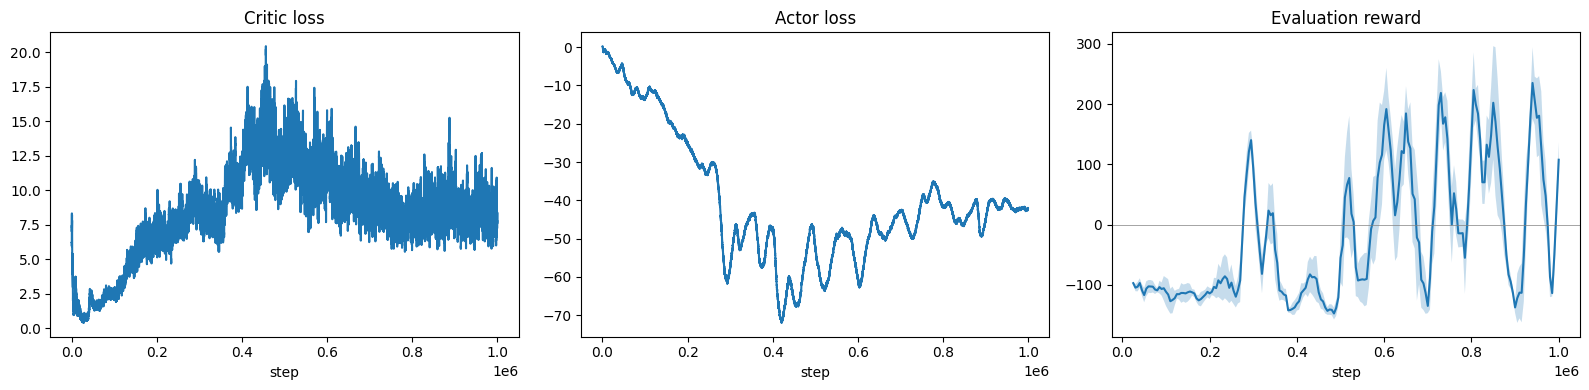

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Сглаживание потерь
def smooth(x, k=500):
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode="valid")

axes[0].plot(smooth(q_loss_hist))
axes[0].set_title("Critic loss")
axes[0].set_xlabel("step")

axes[1].plot(smooth(p_loss_hist))
axes[1].set_title("Actor loss")
axes[1].set_xlabel("step")



eh = np.array(eval_hist)
steps, means, stds = eh[:, 0], eh[:, 1], eh[:, 2]
# сглаживаем средние
k = 5
if len(means) >= k:
    kernel = np.ones(k) / k
    means_s = np.convolve(means, kernel, mode="valid")
    stds_s = np.convolve(stds, kernel, mode="valid")
    steps_s = steps[k - 1:]
else:
    means_s, stds_s, steps_s = means, stds, steps

axes[2].fill_between(steps_s, means_s - stds_s, means_s + stds_s, alpha=0.25)
axes[2].plot(steps_s, means_s, lw=1.5)
axes[2].axhline(0, color="gray", lw=0.5)
axes[2].set_title("Evaluation reward")
axes[2].set_xlabel("step")

plt.tight_layout()
plt.show()

# Testing

Load the best checkpoint, run a few episodes with rendering, and embed the resulting video.

In [16]:
# Load the best policy we found during training
policy_model.load_weights(CHECKPOINT_PATH)

VIDEO_DIR = "videos"
os.makedirs(VIDEO_DIR, exist_ok=True)

test_env = gym.make(ENV_NAME, hardcore=False, render_mode="rgb_array")
test_env = gym.wrappers.RecordVideo(
    test_env,
    video_folder=VIDEO_DIR,
    episode_trigger=lambda ep_id: True,
    name_prefix="bipedal_walker",
)

rewards = []
for ep in range(3):
    obs, _ = test_env.reset()
    total = 0.0
    done = False
    while not done:
        action = policy_model(obs[None])[0].numpy()
        obs, r, terminated, truncated, _ = test_env.step(action)
        total += float(r)
        done = terminated or truncated
    rewards.append(total)
    print(f"Episode {ep + 1}: reward = {total:.2f}")

test_env.close()
print(f"Mean reward over {len(rewards)} episodes: {np.mean(rewards):.2f}")

C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\maxim\RL\2\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 1: reward = 295.93
Episode 2: reward = 293.84
Episode 3: reward = 53.05
Mean reward over 3 episodes: 214.27


In [17]:
# Show the first recorded video inline
from IPython.display import Video

videos = sorted(f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4"))
print("Recorded videos:", videos)
Video(os.path.join(VIDEO_DIR, videos[0]), embed=True) if videos else None

Recorded videos: ['bipedal_walker-episode-0.mp4', 'bipedal_walker-episode-1.mp4', 'bipedal_walker-episode-2.mp4', 'ddpg_bipedal-episode-0.mp4', 'ddpg_bipedal-episode-1.mp4', 'ddpg_bipedal-episode-2.mp4', 'ddpg_bipedal-episode-3.mp4', 'ddpg_bipedal-episode-4.mp4']
